##libraries

In [6]:
!pip -q install diffusers transformers accelerate safetensors torch torchvision pillow matplotlib pandas

##Imports

In [5]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from diffusers import StableDiffusionPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


##Make output folders

In [7]:
os.makedirs("outputs/naive", exist_ok=True)
os.makedirs("outputs/structured", exist_ok=True)
os.makedirs("outputs/controlled", exist_ok=True)

##Load Stable Diffusion

In [8]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = pipe.to(device)

print("Running on:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running on: cpu


##Product metadata

In [9]:
products = [
    {
        "id": "p1",
        "title": "Men's Running Shoes",
        "category": "Footwear",
        "attributes": ["black", "white sole", "sporty", "mesh upper"],
        "style": "studio product photography",
        "background": "clean white background"
    },
    {
        "id": "p2",
        "title": "Women's Leather Handbag",
        "category": "Accessories",
        "attributes": ["brown leather", "gold zipper", "top handle", "luxury"],
        "style": "premium ecommerce photography",
        "background": "clean beige background"
    },
    {
        "id": "p3",
        "title": "Minimalist Ceramic Coffee Mug",
        "category": "Kitchen",
        "attributes": ["matte white", "round handle", "modern", "simple design"],
        "style": "high-quality product photography",
        "background": "clean light gray background"
    }
]

##Prompt generation functions

In [2]:
def create_naive_prompt(product):
    return f"{product['title']}"

def create_structured_prompt(product):
    attrs = ", ".join(product["attributes"])
    return (
        f"{product['title']}, {product['category']}, {attrs}, "
        f"{product['style']}, {product['background']}, centered product shot, highly detailed"
    )

def create_negative_prompt():
    return (
        "blurry, distorted, extra objects, duplicate product, cropped, low quality, "
        "text, watermark, unrealistic proportions, messy background, bad lighting"
    )

##Generate images

In [10]:
generator = torch.Generator(device=device).manual_seed(42)

results = []

for product in products:
    naive_prompt = create_naive_prompt(product)
    structured_prompt = create_structured_prompt(product)
    negative_prompt = create_negative_prompt()

    # Naive
    naive_img = pipe(
        prompt=naive_prompt,
        num_inference_steps=25,
        guidance_scale=7.5,
        generator=generator
    ).images[0]

    naive_path = f"outputs/naive/{product['id']}_naive.png"
    naive_img.save(naive_path)

    # Structured
    structured_img = pipe(
        prompt=structured_prompt,
        num_inference_steps=25,
        guidance_scale=7.5,
        generator=generator
    ).images[0]

    structured_path = f"outputs/structured/{product['id']}_structured.png"
    structured_img.save(structured_path)

    # Controlled
    controlled_img = pipe(
        prompt=structured_prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=25,
        guidance_scale=8.0,
        generator=generator
    ).images[0]

    controlled_path = f"outputs/controlled/{product['id']}_controlled.png"
    controlled_img.save(controlled_path)

    results.append({
        "product_id": product["id"],
        "title": product["title"],
        "naive_prompt": naive_prompt,
        "structured_prompt": structured_prompt,
        "negative_prompt": negative_prompt,
        "naive_path": naive_path,
        "structured_path": structured_path,
        "controlled_path": controlled_path
    })

print("Generation complete.")

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Generation complete.


##Show results

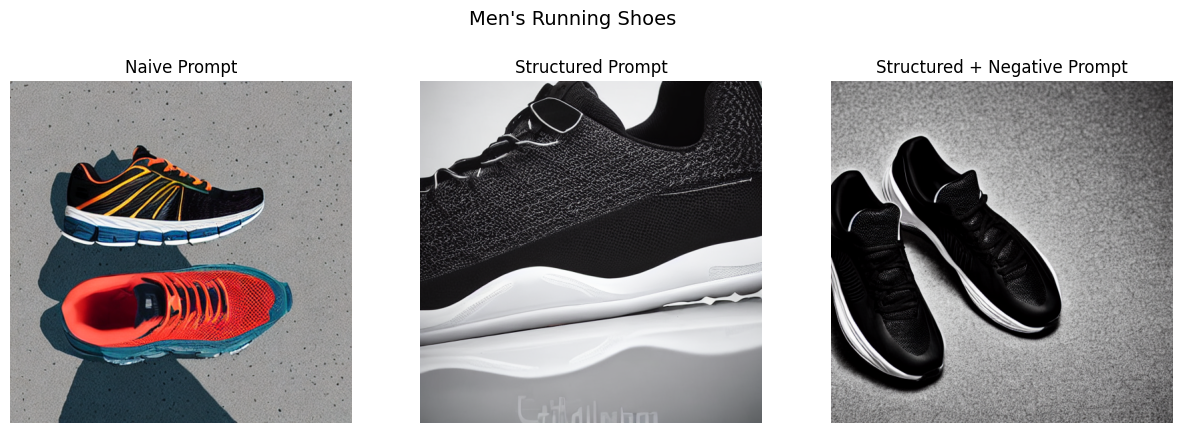

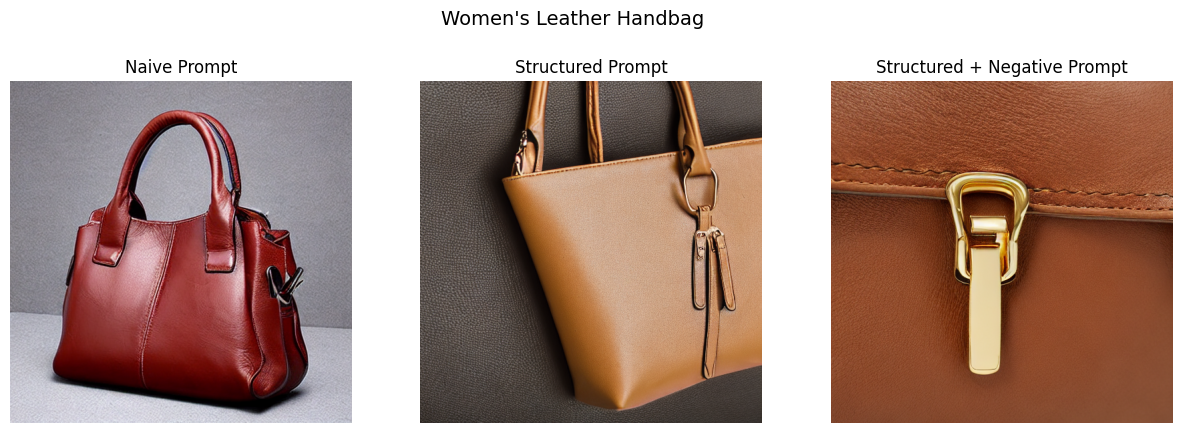

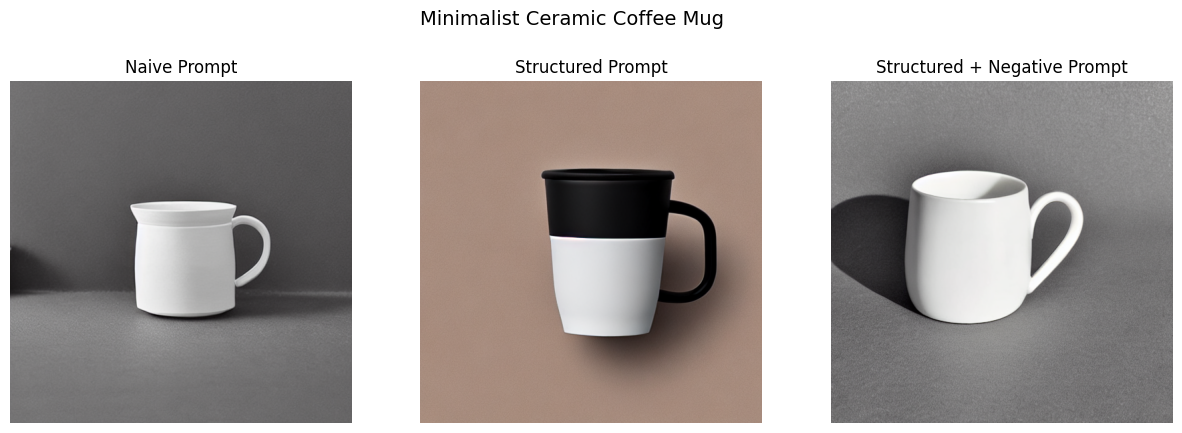

In [11]:
for row in results:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(Image.open(row["naive_path"]))
    axes[0].set_title("Naive Prompt")
    axes[0].axis("off")

    axes[1].imshow(Image.open(row["structured_path"]))
    axes[1].set_title("Structured Prompt")
    axes[1].axis("off")

    axes[2].imshow(Image.open(row["controlled_path"]))
    axes[2].set_title("Structured + Negative Prompt")
    axes[2].axis("off")

    plt.suptitle(row["title"], fontsize=14)
    plt.show()

##Evaluation table

In [14]:
evaluation = pd.DataFrame([
    ["p1", "Men's Running Shoes", 3, 2, 4, 3],
    ["p2", "Women's Leather Handbag", 4, 4, 3, 4],
    ["p3", "Minimalist Ceramic Coffee Mug", 5, 4, 2, 5]
], columns=[
    "product_id",
    "title",
    "prompt_alignment",
    "consistency",
    "diversity",
    "quality"
])

evaluation

,product_id,title,prompt_alignment,consistency,diversity,quality
0,p1,Men's Running Shoes,3,2,4,3
1,p2,Women's Leather Handbag,4,4,3,4
2,p3,Minimalist Ceramic Coffee Mug,5,4,2,5


Save evaluation to CSV

In [16]:
evaluation.to_csv("outputs/evaluation_results.csv", index=False)
print("Saved evaluation_results.csv")

Saved evaluation_results.csv
